0.15652475842498523


/root/miniconda3/envs/mp/lib/python3.9/site-packages/meep/visualization.py:533: UserWarning: The frequency parameter of plot2D has been deprecated. Use the frequency key of the eps_parameters dictionary instead.
  warnings.warn(


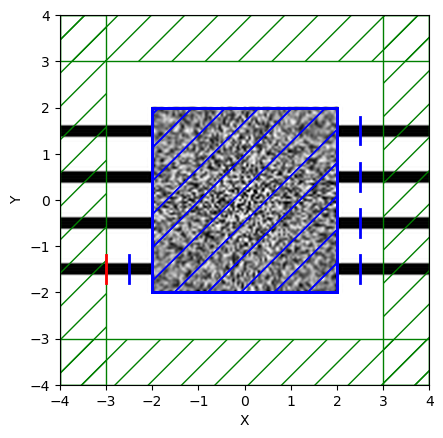

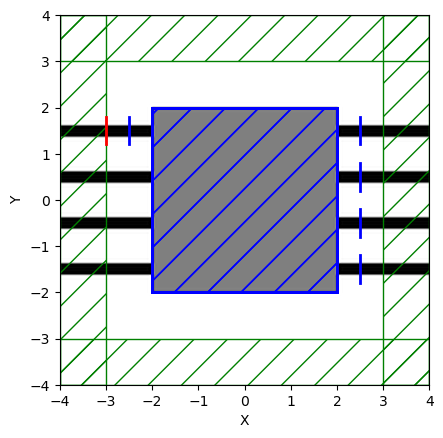

In [1]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 20

# cell size
Sx = 8
Sy = 8
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(1.0)]

# source
port_ys = [1.5, 0.5, -0.5, -1.5]

fcen = 1 / 1.55

width = 0.6
source_size = mp.Vector3(0, 0.6, 0)

source_x = -3

target_matrix = np.array([
    [1/4, 1/4, 1/4, 1/4],
    [0,   1/3, 1/3, 1/3],
    [0,   0,   1/2, 1/2],
    [0,   0,   0,   1  ],
])


def make_source(case_idx):
    """
    case_idx = 0: port 1 input, lambda = 1.55 um
    case_idx = 1: port 2 input, lambda = 1.55 um
    case_idx = 2: port 3 input, lambda = 1.55 um
    case_idx = 3: port 4 input, lambda = 1.55 um
    """

    fwidth = width * fcen

    src = mp.GaussianSource(
        frequency=fcen,
        fwidth=fwidth
    )

    source = [
        mp.EigenModeSource(
            src,
            eig_band=1,
            eig_match_freq=True,
            direction=mp.X,
            size=source_size,
            center=mp.Vector3(source_x, port_ys[case_idx], 0),
        )
    ]

    return source

#design region
Dx = 4
Dy = 4
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution) + 1
Ny = int(Dy * design_region_resolution) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))

# geometry
wg_width = 0.25

wg_length = (Sx - Dx) / 2

x_in = -Dx/2 - wg_length/2
x_out = Dx/2 + wg_length/2

geometry = []

# input / output waveguides
for y in port_ys:
    # input waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables
    )
)
# filter
minimum_length = 0.07
eta_i = (
    0.5
)
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
print(filter_radius)
design_region_resolution = int(1 * resolution)

def mapping(x, eta, beta):
    x = npa.reshape(x, (Nx, Ny))

    # filter
    filtered_field = mpa.conic_filter(
        x,
        filter_radius,
        Dx,
        Dy,
        design_region_resolution,
    )

    # projection
    projected_field = mpa.tanh_projection(filtered_field, beta, eta)
    # interpolate to actual materials
    return projected_field.flatten()

# FOM
def make_J(case_idx):

    target = npa.array(target_matrix[case_idx])
    target_norm = npa.mean(target ** 2) + 1e-12

    def J(a_in, a1, a2, a3, a4):
        Pin = npa.squeeze(npa.abs(a_in) ** 2) + 1e-12

        powers = npa.array([
            npa.squeeze(npa.abs(a1) ** 2),
            npa.squeeze(npa.abs(a2) ** 2),
            npa.squeeze(npa.abs(a3) ** 2),
            npa.squeeze(npa.abs(a4) ** 2)
        ])

        T = powers / Pin

        mse = npa.mean((T - target) ** 2)

        fom = 1 - mse / target_norm

        return fom

    return J


opt_list = []

for case_idx in range(4):

    source = make_source(case_idx)

    sim = mp.Simulation(
        cell_size=cell_size,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=source,
        eps_averaging=False,
        resolution=resolution,
    )

    # input monitor
    TE_in = mpa.EigenmodeCoefficient(
        sim,
        mp.Volume(
            center=mp.Vector3(-2.5, port_ys[case_idx], 0),
            size=mp.Vector3(y=0.6)
        ),
        mode=1,
        forward=True
    )

    # output monitors
    TE_out = []

    for y in port_ys:
        TE_out.append(
            mpa.EigenmodeCoefficient(
                sim,
                mp.Volume(
                    center=mp.Vector3(2.5, y, 0),
                    size=mp.Vector3(y=0.6)
                ),
                mode=1
            )
        )

    ob_list = [TE_in] + TE_out

    J_case = make_J(case_idx)

    opt = mpa.OptimizationProblem(
        simulation=sim,
        objective_functions=J_case,
        objective_arguments=ob_list,
        design_regions=[design_region],
        fcen=fcen,
        df=0,
        nf=1,
    )

    opt_list.append(opt)

x0 = np.random.rand(Nx * Ny)
opt.update_design([x0])

opt.plot2D(True, frequency=1 / 1.55)
plt.show()

x0 = 0.5 * np.ones((Nx * Ny,))

for opt_case in opt_list:
    opt_case.update_design([x0])

opt_list[0].plot2D(True, frequency=1 / 1.55)
plt.show()


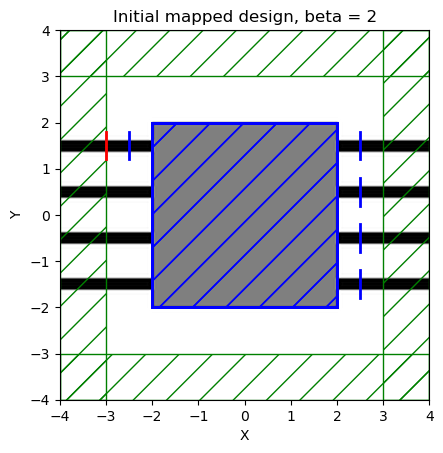


Starting beta = 2
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


...

Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
Starting forward run...


Starting adjoint run...


Calculating gradient...
iter 200 | beta = 32.00 | FOM = 0.86138704 | cases = [0.9153, 0.8965, 0.8847, 0.7490]
Finished beta = 32.00 | FOM = 0.86138704 | stop reason = maxeval_per_beta = 40 | NLopt result = 5

Optimization finished at beta = 32

Optimization finished.
Final beta = 32
Final FOM = 0.86138704
Final NLopt result = 5
Final design min = 0.000000
Final design max = 1.000000


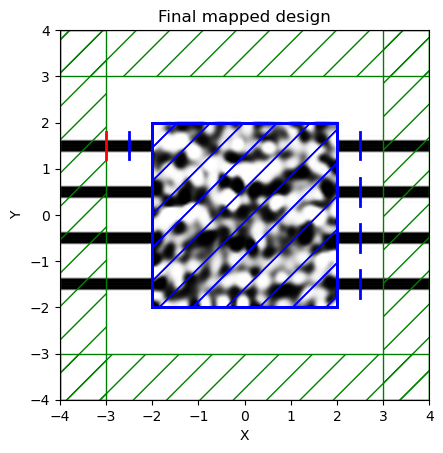

In [2]:
# optimization setting

evaluation_history = []
case_history = []
cur_iter = [0]

num_design_variables = Nx * Ny
num_cases = len(opt_list)

algorithm = nlopt.LD_MMA
case_weights = np.ones(num_cases) / num_cases


# gradient reshape function
def get_gradient_array(dJ_du):
    g = dJ_du
    while isinstance(g, (list, tuple)):
        g = g[0]
    g = np.real(np.squeeze(np.asarray(g)))
    g = g.reshape(-1)

    return g



# objective function for NLopt
def f(v, gradient, beta):
    cur_iter[0] += 1
    u = mapping(v, eta_i, beta)

    total_fom = 0.0

    dJ_du_total = np.zeros(num_design_variables)

    case_foms = []

    for case_idx, opt_case in enumerate(opt_list):

        fom_i, dJ_du_i = opt_case([u], need_gradient=True)

        fom_i = float(np.real(np.squeeze(fom_i)))
        g_i = get_gradient_array(dJ_du_i)

        if g_i.size != num_design_variables:
            raise ValueError(
                f"Gradient size mismatch at case {case_idx}: "
                f"got {g_i.size}, expected {num_design_variables}"
            )

        w = case_weights[case_idx]

        total_fom += w * fom_i
        dJ_du_total += w * g_i

        case_foms.append(fom_i)

    # mapping chain rule
    if gradient.size > 0:
        dJ_dv = vjp(mapping, 0)(v, eta_i, beta, dJ_du_total)
        dJ_dv = np.real(np.asarray(dJ_dv)).reshape(-1)

        if dJ_dv.size != num_design_variables:
            raise ValueError(
                f"Mapped gradient size mismatch: "
                f"got {dJ_dv.size}, expected {num_design_variables}"
            )

        gradient[:] = dJ_dv

    evaluation_history.append(total_fom)
    case_history.append(case_foms)

    print(
        f"iter {cur_iter[0]:03d} | "
        f"beta = {beta:.2f} | "
        f"FOM = {total_fom:.8f} | "
        f"cases = [{case_foms[0]:.4f}, {case_foms[1]:.4f}, "
        f"{case_foms[2]:.4f}, {case_foms[3]:.4f}]"
    )

    return total_fom



# initial raw design
x_raw = 0.5 * np.ones((Nx * Ny,))

target_fom = 0.9

cur_beta = 2
beta_scale = 2
max_beta = 32

maxeval_per_beta = 40

last_beta = cur_beta
final_fom = None
final_result = None



# initial mapped design plot
x_init_mapped = np.array(mapping(x_raw, eta_i, cur_beta))
x_init_mapped = np.clip(x_init_mapped, 0.0, 1.0)

for opt_case in opt_list:
    opt_case.update_design([x_init_mapped])

opt_list[0].plot2D(True, frequency=fcen)
plt.title(f"Initial mapped design, beta = {cur_beta}")
plt.show()



# beta continuation optimization
while cur_beta <= max_beta:

    beta_this = cur_beta
    last_beta = beta_this

    print()
    print(f"Starting beta = {beta_this}")

    solver = nlopt.opt(algorithm, num_design_variables)

    solver.set_lower_bounds(np.zeros(num_design_variables))
    solver.set_upper_bounds(np.ones(num_design_variables))
    solver.set_max_objective(lambda a, g, b=beta_this: f(a, g, b))
    solver.set_maxeval(maxeval_per_beta)
    solver.set_stopval(target_fom)
    x_raw = solver.optimize(x_raw)
    x_raw = np.clip(x_raw, 0.0, 1.0)

    current_fom = solver.last_optimum_value()
    final_fom = current_fom
    final_result = solver.last_optimize_result()

    x_mapped = np.array(mapping(x_raw, eta_i, beta_this))
    x_mapped = np.clip(x_mapped, 0.0, 1.0)

    for opt_case in opt_list:
        opt_case.update_design([x_mapped])

    if current_fom >= target_fom:
        stop_reason = f"FOM >= {target_fom}"
    else:
        stop_reason = f"maxeval_per_beta = {maxeval_per_beta}"

    print(
        f"Finished beta = {beta_this:.2f} | "
        f"FOM = {current_fom:.8f} | "
        f"stop reason = {stop_reason} | "
        f"NLopt result = {final_result}"
    )

    if beta_this == max_beta:
        print()
        print(f"Optimization finished at beta = {beta_this}")
        break
    cur_beta = cur_beta * beta_scale


# final design
x_raw_final = x_raw.copy()
x = np.array(mapping(x_raw_final, eta_i, last_beta))
x = np.clip(x, 0.0, 1.0)

for opt_case in opt_list:
    opt_case.update_design([x])

print()
print("Optimization finished.")
print(f"Final beta = {last_beta}")
print(f"Final FOM = {final_fom:.8f}")
print(f"Final NLopt result = {final_result}")
print(f"Final design min = {np.min(x):.6f}")
print(f"Final design max = {np.max(x):.6f}")

opt_list[0].plot2D(True, frequency=fcen)
plt.title("Final mapped design")
plt.show()



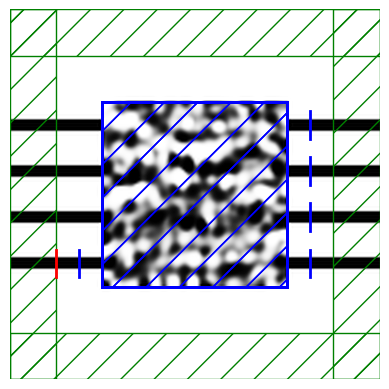

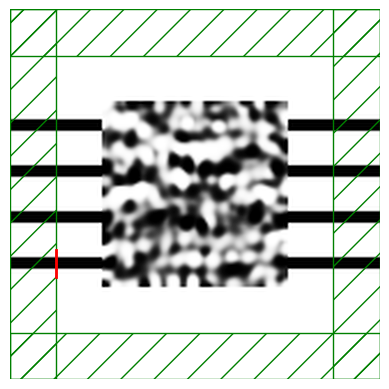

In [3]:
opt.update_design([x])
opt.plot2D(
    True,
    plot_monitors_flag=False,
    output_plane=mp.Volume(center=(0,0,0), size=(8,8,0))
)
plt.axis("off")

opt.update_design([x])

plt.figure()
sim.plot2D(
    output_plane=mp.Volume(center=mp.Vector3(), size=mp.Vector3(8,8,0)),
    labels=False
)
plt.axis("off")
plt.show()

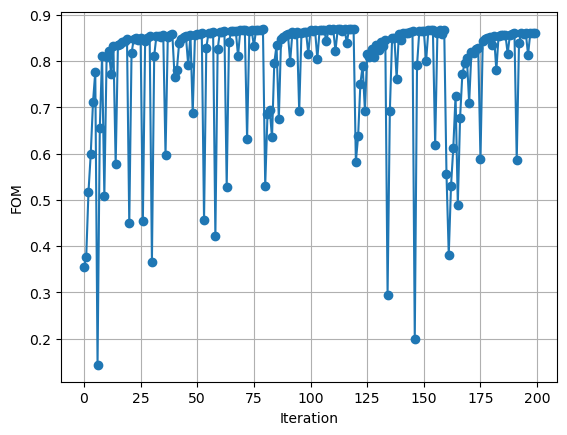

In [4]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import meep as mp

# ==================================================
# 여기만 바꾸면 됨
# case_to_plot = 0, 1, 2, 3
# 0 -> λ=1.55 um, input port 1
# 1 -> λ=1.56 um, input port 2
# 2 -> λ=1.57 um, input port 3
# 3 -> λ=1.58 um, input port 4
# ==================================================
case_to_plot = 3

# Plot할 design 선택
design_to_plot = x  # 최적화 후 구조: x, 초기 구조: x0

# case별 wavelength
wavelengths = [1.55, 1.55, 1.55, 1.55]

case_idx = case_to_plot
lambda_case = wavelengths[case_idx]
fcen_case = 1 / lambda_case
input_y = port_ys[case_idx]
target_case = target_matrix[case_idx]

# ==================================================
# Design variable 생성
# ==================================================
plot_design_variables = mp.MaterialGrid(
    mp.Vector3(Nx, Ny),
    mp.air,
    Si,
    weights=design_to_plot.reshape((Nx, Ny)),
    grid_type="U_MEAN"
)

# ==================================================
# Geometry 생성
# ==================================================
geometry_plot = []

for y in port_ys:
    # input waveguide
    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_in, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

    # output waveguide
    geometry_plot.append(
        mp.Block(
            center=mp.Vector3(x_out, y),
            size=mp.Vector3(wg_length, wg_width, mp.inf),
            material=Si
        )
    )

# OSU design region
geometry_plot.append(
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=plot_design_variables
    )
)

# ==================================================
# Case별 source 생성
# ==================================================
source_case = make_source(case_idx)

# ==================================================
# Simulation 생성
# ==================================================
sim_plot = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry_plot,
    sources=source_case,
    eps_averaging=False,
    resolution=resolution,
)

# ==================================================
# Input flux monitor
# ==================================================
input_flux = sim_plot.add_flux(
    fcen_case, 0, 1,
    mp.FluxRegion(
        center=mp.Vector3(-2.5, input_y, 0),
        size=mp.Vector3(0, 0.6, 0)
    )
)

# ==================================================
# Output flux monitors
# ==================================================
output_fluxes = []

for y in port_ys:
    output_fluxes.append(
        sim_plot.add_flux(
            fcen_case, 0, 1,
            mp.FluxRegion(
                center=mp.Vector3(2.5, y, 0),
                size=mp.Vector3(0, 0.6, 0)
            )
        )
    )

# ==================================================
# Field monitor
# ==================================================
dft_fields = sim_plot.add_dft_fields(
    [mp.Ez],
    fcen_case,
    0,
    1,
    center=mp.Vector3(),
    size=cell_size
)

# ==================================================
# Simulation 실행
# ==================================================
sim_plot.run(
    until_after_sources=mp.stop_when_fields_decayed(
        50,
        mp.Ez,
        mp.Vector3(2.5, input_y, 0),
        1e-6
    )
)

# ==================================================
# Field와 dielectric data 추출
# ==================================================
ez_dft = sim_plot.get_dft_array(dft_fields, mp.Ez, 0)

eps_data = sim_plot.get_array(
    center=mp.Vector3(),
    size=cell_size,
    component=mp.Dielectric
)

# ==================================================
# Field plot 값 생성
# ==================================================
field_amp = np.abs(ez_dft)

vref = np.percentile(field_amp, 99.5)
field_plot = field_amp / (vref + 1e-12) * 2.0
field_plot = np.clip(field_plot, 0, 2.0)

# ==================================================
# Input 기준 transmission 계산
# ==================================================
Pin = mp.get_fluxes(input_flux)[0]
Pin = max(Pin, 1e-12)

Pout = np.array([max(mp.get_fluxes(f)[0], 0) for f in output_fluxes])
T_values = Pout / Pin

# ==================================================
# Plot
# ==================================================
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    field_plot.T,
    origin="lower",
    cmap="magma",
    extent=[-Sx/2, Sx/2, -Sy/2, Sy/2],
    interpolation="spline36",
    vmin=0,
    vmax=2.0
)

# Structure contour
eps_air = 1.0
eps_si = 3.4**2
eps_level = (eps_air + eps_si) / 2

ax.contour(
    eps_data.T,
    levels=[eps_level],
    colors="0.6",
    linewidths=0.6,
    origin="lower",
    extent=[-Sx/2, Sx/2, -Sy/2, Sy/2]
)

# Input port label
for i, y in enumerate(port_ys):
    input_label = "1" if i == case_idx else "0"

    ax.text(
        -Sx/2 + 0.35,
        y,
        input_label,
        color="white",
        fontsize=12,
        ha="left",
        va="center",
        weight="bold"
    )

# Output transmission label
for i, y in enumerate(port_ys):
    ax.text(
        Sx/2 - 0.35,
        y,
        f"{100 * T_values[i]:.1f}%",
        color="white",
        fontsize=12,
        ha="right",
        va="center",
        weight="bold"
    )

# Wavelength label
ax.text(
    -Sx/2 + 0.45,
    Sy/2 - 0.65,
    rf"$\lambda = {lambda_case:.2f}\ \mu m$",
    color="white",
    fontsize=15,
    weight="bold"
)

ax.set_title(
    f"Input port {case_idx + 1}",
    fontsize=13
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([-Sx/2, Sx/2])
ax.set_ylim([-Sy/2, Sy/2])

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label(r"$|E_z|$", fontsize=12)

plt.tight_layout()
plt.show()

# ==================================================
# Transmission summary 출력
# ==================================================
print("Transmission summary")
print()
print(f"Case: {case_idx}")
print(f"Input port: {case_idx + 1}")
print(f"Lambda: {lambda_case:.2f} um")
print()

for i in range(4):
    print(f"T{i+1} = {100 * T_values[i]:.2f}%")

print()
print("Target:")
for i in range(4):
    print(f"target {i+1} = {target_case[i]}")

NameError: name 'x' is not defined